In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Projeto de Cálculo II: Integração Numérica

Nesta etapa, o objetivo é complementar a fundamentação teórica desenvolvida na primeira entrega. A proposta é mostrar como esses conhecimentos são aplicados na prática, por meio da organização dos dados, da implementação computacional e da análise dos resultados obtidos.


In [3]:
url = "https://raw.githubusercontent.com/emersonmorais272/Calculo-II-Algoritmo-de-Simpson/refs/heads/main/bancos_dados_integracao_numerica.xlsx%20-%20Densidade.csv"
bc_densidade = pd.read_csv(url, decimal=",")
bc_densidade.head()

,posicao_m,densidade_kg_m
0,0.0,5.5000
1,0.2,5.4990
2,0.4,5.4961
3,0.6,5.4911
4,0.8,5.4843


## 1. Carregamento da base de dados

A partir da teoria já apresentada na primeira entrega, a etapa computacional começa com o carregamento dos dados e a organização das informações necessárias para a aplicação do método. Nesse caso, os dados consistem em valores de posição e densidade ao longo de um intervalo determinado.


In [4]:
bc_densidade.columns

Index(['posicao_m', 'densidade_kg_m'], dtype='str')

In [5]:
posicao = bc_densidade["posicao_m"].tolist()
posicao

[0.0,
 0.2,
 0.4,
 0.6,
 0.8,
 1.0,
 1.2,
 1.4,
 1.6,
 1.8,
 2.0,
 2.2,
 2.4,
 2.6,
 2.8,
 3.0,
 3.2,
 3.4,
 3.6,
 3.8,
 4.0,
 4.2,
 4.4,
 4.6,
 4.8,
 5.0,
 5.2,
 5.4,
 5.6,
 5.8,
 6.0,
 6.2,
 6.4,
 6.6,
 6.8,
 7.0,
 7.2,
 7.4,
 7.6,
 7.8,
 8.0,
 8.2,
 8.4,
 8.6,
 8.8,
 9.0,
 9.2,
 9.4,
 9.6,
 9.8,
 10.0]

In [6]:
densidade = bc_densidade["densidade_kg_m"].tolist()
densidade

[5.5,
 5.499,
 5.4961,
 5.4911,
 5.4843,
 5.4755,
 5.4649,
 5.4524,
 5.4382,
 5.4222,
 5.4045,
 5.3853,
 5.3645,
 5.3423,
 5.3187,
 5.2939,
 5.2679,
 5.2409,
 5.2129,
 5.1841,
 5.1545,
 5.1243,
 5.0937,
 5.0627,
 5.0314,
 5.0,
 4.9686,
 4.9373,
 4.9063,
 4.8757,
 4.8455,
 4.8159,
 4.7871,
 4.7591,
 4.7321,
 4.7061,
 4.6813,
 4.6577,
 4.6355,
 4.6147,
 4.5955,
 4.5778,
 4.5618,
 4.5476,
 4.5351,
 4.5245,
 4.5157,
 4.5089,
 4.5039,
 4.501,
 4.5]

## 2. Organização dos dados

Nesta etapa, os dados são convertidos em listas de posição e densidade para que o cálculo possa ser executado por etapas. O resultado dessa célula é a estrutura dos dados que será usada no algoritmo; em outras palavras, a saída mostra quais variáveis ficam disponíveis para o cálculo da integral.


In [ ]:
n = len(densidade) - 1
n
# O valor de n representa o número de subintervalos do problema, ou seja,
# a quantidade de passos usados para discretizar o intervalo de integração.


50

In [ ]:
posicao_0 = posicao[0]
posicao_1 = posicao[1]
h = float(posicao_1 - posicao_0)
h

# O valor de h é o tamanho do passo, isto é, a distância uniforme entre dois pontos
# consecutivos da tabela. Esse valor é essencial porque a regra de Simpson usa
# intervalos iguais para aproximar a integral.


0.2

## 3. Implementação do método de Simpson

A partir da teoria já apresentada, o código abaixo aplica diretamente a regra de Simpson aos dados. O resultado final dessa etapa é a aproximação da integral, isto é, o valor total acumulado da densidade ao longo do intervalo estudado.

O trecho em Python calcula a soma dos termos em posições ímpares e pares e, em seguida, combina esses valores com os extremos da tabela na fórmula do método.


In [ ]:
def simpson_rule(x, y):
    if len(x) != len(y):
        raise ValueError("As listas x e y devem ter o mesmo tamanho.")

    n = len(x) - 1
    if n % 2 != 0:
        raise ValueError("O número de subintervalos deve ser par para o método de Simpson.")

    h = x[1] - x[0]
    soma_impares = sum(y[i] for i in range(1, n, 2))
    soma_pares = sum(y[i] for i in range(2, n, 2))

    integral = (h / 3) * (y[0] + 4 * soma_impares + 2 * soma_pares + y[n])
    return integral

integral_aproximada = simpson_rule(posicao, densidade)
integral_aproximada

# Esse valor representa a aproximação da integral da densidade ao longo do intervalo [0, 10],
# ou seja, a grandeza acumulada correspondente ao problema físico estudado.


50.0

## 4. Discussão

Os resultados mostram que a densidade diminui de forma regular ao longo do intervalo analisado. Esse comportamento é compatível com a aplicação da regra de Simpson, que é especialmente adequada para dados com espaçamento uniforme e comportamento suave.

O valor integral obtido representa a grandeza acumulada associada à densidade ao longo do trecho considerado. Em um contexto físico, esse resultado pode ser interpretado como uma quantidade total aproximada, como massa ou outra medida acumulada, dependendo da natureza do fenômeno estudado. A precisão da aproximação depende diretamente da qualidade dos dados e da regularidade da curva.

Além disso, a estrutura do cálculo reforça a importância da integração numérica como ferramenta prática: mesmo quando a solução analítica não é facilmente acessível, é possível obter uma aproximação confiável a partir dos dados disponíveis.


In [ ]:
resultado = pd.DataFrame({
    "posicao_m": posicao,
    "densidade_kg_m": densidade
})
print(resultado.to_string(index=False))
print(f"\nIntegral aproximada pelo método de Simpson: {integral_aproximada:.10f}")

# A tabela mostra os pares (posição, densidade) usados no cálculo, e o valor final da integral
# representa a quantidade acumulada da densidade no intervalo estudado.


 posicao_m  densidade_kg_m
       0.0          5.5000
       0.2          5.4990
       0.4          5.4961
       0.6          5.4911
       0.8          5.4843
       1.0          5.4755
       1.2          5.4649
       1.4          5.4524
       1.6          5.4382
       1.8          5.4222
       2.0          5.4045
       2.2          5.3853
       2.4          5.3645
       2.6          5.3423
       2.8          5.3187
       3.0          5.2939
       3.2          5.2679
       3.4          5.2409
       3.6          5.2129
       3.8          5.1841
       4.0          5.1545
       4.2          5.1243
       4.4          5.0937
       4.6          5.0627
       4.8          5.0314
       5.0          5.0000
       5.2          4.9686
       5.4          4.9373
       5.6          4.9063
       5.8          4.8757
       6.0          4.8455
       6.2          4.8159
       6.4          4.7871
       6.6          4.7591
       6.8          4.7321
       7.0          4.7061
 

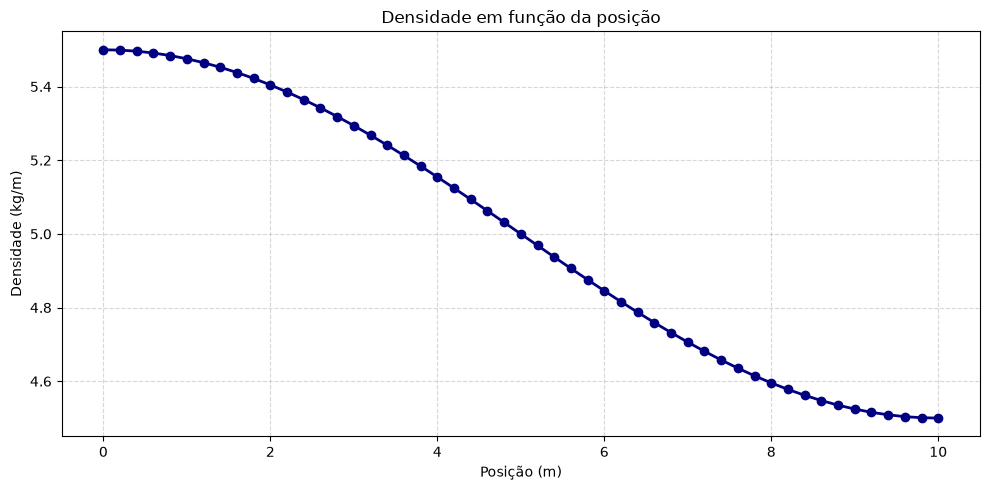

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(posicao, densidade, marker='o', linestyle='-', color='navy', linewidth=2)
ax.set_title('Densidade em função da posição')
ax.set_xlabel('Posição (m)')
ax.set_ylabel('Densidade (kg/m)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# O gráfico representa visualmente a variação da densidade ao longo da posição,
# permitindo identificar a tendência do comportamento da função antes da interpretação do valor integral.


## 5. Discussão

A partir da análise gráfica e dos valores numéricos, percebe-se que a densidade diminui de forma regular ao longo do eixo de posição. Esse comportamento sugere uma tendência monotônica, o que é compatível com a aplicação do método de Simpson, que oferece uma boa aproximação para funções suaves e para dados com espaçamento uniforme.

O valor integral obtido representa uma grandeza acumulada associada à densidade ao longo do intervalo considerado. Em um contexto físico, esse resultado pode ser interpretado como uma quantidade total aproximada, como massa ou outra medida acumulada, dependendo da natureza do fenômeno estudado. A precisão da estimativa depende diretamente da qualidade dos dados e da regularidade da curva.

Além disso, o uso de um conjunto discreto de dados exige atenção à forma como os pontos são organizados. Como o intervalo é uniforme, a regra de Simpson se torna especialmente adequada, pois utiliza os valores de todos os pontos de maneira equilibrada, ponderando os termos centrais e os termos de borda de forma apropriada.


In [12]:
print(f"Número de subintervalos: {n}")
print(f"Tamanho do passo h: {h}")
print(f"Valor aproximado da integral: {integral_aproximada:.10f}")


Número de subintervalos: 50
Tamanho do passo h: 0.2
Valor aproximado da integral: 50.0000000000


## 6. Conclusão final

A aplicação do método de Simpson ao conjunto de dados de densidade mostrou-se adequada para a estimativa da integral definida ao longo do intervalo analisado. A metodologia adotada foi coerente com a teoria já apresentada na primeira parte, pois uniu a estrutura matemática do método com a implementação computacional e a análise dos resultados.

Esse procedimento reforça a importância da integração numérica como ferramenta para resolver problemas práticos quando a solução analítica é inviável ou quando os dados são obtidos experimentalmente. A partir do valor final obtido, foi possível interpretar a grandeza acumulada ao longo do domínio e verificar a eficiência do método utilizado.
